In [21]:
import os, sys, subprocess, shutil, time

GITHUB_REPO = "https://github.com/hugoaslm/leap-graph-efm-shift.git"
NEURAL_LAM_REPO = "https://github.com/mllam/neural-lam.git"
NEURAL_LAM_BRANCH = "prob_model_global"

RUN_PROFILE = "l4_core"
DO_PREPROCESS = True
DO_TRAIN = True
DO_EVALUATE = True
DO_PLOT = True

from google.colab import drive
drive.mount("/content/drive")

DRIVE_ROOT = "/content/drive/MyDrive/leap_project"
PROJECT_DIR = "/content/leap_project"
REPO_DIR = os.path.join(PROJECT_DIR, "leap-graph-efm-shift")
NLAM_DIR = os.path.join(PROJECT_DIR, "neural-lam-prob-model")
os.makedirs(DRIVE_ROOT, exist_ok=True)
os.makedirs(PROJECT_DIR, exist_ok=True)

if not os.path.exists(REPO_DIR):
    !git clone {GITHUB_REPO} {REPO_DIR} 2>&1 | tail -3
else:
    %cd {REPO_DIR}
    !git pull 2>&1 | tail -3
    %cd {PROJECT_DIR}

%cd {PROJECT_DIR}

if not os.path.exists(NLAM_DIR):
    !git clone --branch {NEURAL_LAM_BRANCH} {NEURAL_LAM_REPO} {NLAM_DIR} 2>&1 | tail -3

patches_src = os.path.join(REPO_DIR, "neural-lam-patches")
if os.path.exists(patches_src):
    for root, dirs, files in os.walk(patches_src):
        rel = os.path.relpath(root, patches_src)
        for f in files:
            src = os.path.join(root, f)
            dst = os.path.join(NLAM_DIR, rel, f)
            os.makedirs(os.path.dirname(dst), exist_ok=True)
            shutil.copy2(src, dst)
    ct_path = os.path.join(NLAM_DIR, "neural_lam", "constants.py")
    with open(ct_path) as fh:
        if "load_experiment_config" not in fh.read():
            raise RuntimeError("constants.py patch missing — did you push neural-lam-patches/ ?")
    print("Patches verified.")
else:
    raise RuntimeError(f"neural-lam-patches/ not found at {patches_src}")

for d in ["checkpoints", "results", "figures", "data"]:
    os.makedirs(os.path.join(PROJECT_DIR, d), exist_ok=True)

sys.path.insert(0, NLAM_DIR)
print("Setup done.")



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/leap_project/leap-graph-efm-shift
 notebooks/graph_efm_temporal_shift_colab.ipynb |  6 ++++-
 scripts/plot_shift_results.py                  | 33 ++++++++++----------------
 2 files changed, 18 insertions(+), 21 deletions(-)
/content/leap_project
/content/leap_project
Patches verified.
Setup done.


In [2]:
!pip install -q scipy matplotlib "xarray>=2024.2.0" "zarr>=2.17.1,<3" gcsfs dask wandb pyyaml tqdm
!pip install -q pytorch-lightning torch-geometric==2.3.1
!pip install -q shapely networkx Cartopy pyproj tueplots
!pip install -q git+https://github.com/deepmind/graphcast.git 2>&1 | tail -2
!pip install -q parse dataclass-wizard
import numpy as np
import importlib.metadata as _im
_disk_np = _im.version("numpy")
print("Dependencies installed. numpy", np.__version__, "(disk", _disk_np + ")")
if np.__version__ != _disk_np:
    raise SystemExit("MIXED NUMPY INSTALL: kernel loaded numpy "
                     f"{np.__version__} but disk has {_disk_np}. "
                     "Fix: Runtime > Restart session, then run all cells again.")



  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.3/211.3 kB 18.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 130.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.6/661.6 kB 46.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 55.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 74.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 145.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ibis-framework 9.5.0 requires toolz<1,>=0.11, but you have toolz 1.1.0 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.4/53.4 kB 5.5 MB/s eta 0

In [3]:
import importlib, yaml
from neural_lam import constants
importlib.reload(constants)

CONFIG_PATH = os.path.join(REPO_DIR, "configs", "wb2_shift_64x32_graph_efm.yaml")
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

constants.load_experiment_config(CONFIG_PATH)

data_name = cfg["dataset"]["name"]
drive_data = os.path.join(DRIVE_ROOT, "data", data_name)
local_data = os.path.join(PROJECT_DIR, "data", data_name)
nl_data = os.path.join(NLAM_DIR, "data", data_name)
os.makedirs(local_data, exist_ok=True)
os.makedirs(nl_data, exist_ok=True)

print(f"Grid: {constants.GRID_SHAPE},  vars: {constants.PARAM_NAMES_SHORT}")
print(f'Splits: train {cfg["splits"]["train"]}, val {cfg["splits"]["val"]}')
print(f'        id {cfg["splits"]["id"]}, ood {cfg["splits"]["ood"]}')



[constants] Loaded experiment config from /content/leap_project/leap-graph-efm-shift/configs/wb2_shift_64x32_graph_efm.yaml
  GRID_SHAPE = (64, 32)
  GRID_STATE_DIM = 3
  ATMOSPHERIC_PARAMS = ['geopotential', 'temperature']
  SURFACE_PARAMS = ['2m_temperature']
  PRESSURE_LEVELS = [500, 850]
  PARAM_NAMES_SHORT = ['z500', 't850', 't2m']
  VAL_STEP_LOG_ERRORS = [ 1  2  4  6  8 10 12]
Grid: (64, 32),  vars: ['z500', 't850', 't2m']
Splits: train ['1979-01-01', '2005-12-31'], val ['2006-01-01', '2010-12-31']
        id ['2011-01-01', '2015-12-31'], ood ['2016-01-01', '2022-12-31']


In [4]:
if not DO_PREPROCESS:
    print("Skipping preprocessing.")
else:
    !python {REPO_DIR}/scripts/prepare_colab_data.py --config {CONFIG_PATH} --project {PROJECT_DIR} --nl {NLAM_DIR} --repo {REPO_DIR} --drive {DRIVE_ROOT}


Copying data archive from Drive (1.9 GB)...
  archive copied in 23s
  archive extracted in 5s
  [fields.zarr (download) done in 50s]
  [fields.zarr (rechunk/validate) done in 50s]
Restoring graph from archive: /content/leap_project/neural-lam-prob-model/graphs/global_hierarchical_64x32
Running preprocessing step: forcing (pending: forcing)
Running /usr/bin/python3 /content/leap_project/neural-lam-prob-model/create_global_forcing.py --dataset wb2_era5_64x32 --time_start 1979-01-01 --time_end 2022-12-31
Constructing timestamps
Generating TOA radiation (jitted, 60 integration bins; ~1 min)
  TOA radiation done in 43s
Generating day + year progress features
  progress features done in 0s
Saving xarray
Writing forcing.zarr...
[########################################] | 100% Completed | 749.52 ms
  wrote forcing.zarr in 2s
Done!
[forcing took 59s]
Copying to local: /content/leap_project/neural-lam-prob-model/data/wb2_era5_64x32/forcing.zarr
Running preprocessing step: grid_features (pending

In [5]:
%cd {PROJECT_DIR}
import numpy as np
import importlib.metadata as _im
if np.__version__ != _im.version("numpy"):
    raise SystemExit("MIXED NUMPY INSTALL. Fix: Runtime > Restart session, then re-run all cells.")
import torch
from neural_lam.models.graph_efm import GraphEFM
from types import SimpleNamespace

mc, fc, gc, ev = cfg["model"], cfg["forecast"], cfg["graph"], cfg["evaluation"]
args = SimpleNamespace(
    hidden_dim=mc["hidden_dim"], latent_dim=mc["latent_dim"],
    hidden_layers=mc["hidden_layers"],
    processor_layers=mc["decoder_processor_layers"],
    encoder_processor_layers=mc["encoder_processor_layers"],
    prior_processor_layers=mc["prior_processor_layers"],
    kl_beta=mc["kl_beta"], crps_weight=mc["crps_weight"],
    loss=mc["loss"], sample_obs_noise=mc["sample_obs_noise"],
    output_std=mc["output_std"], prior_dist=mc["prior_dist"],
    learn_prior=mc["learn_prior"],
    graph=gc["name"], dataset=cfg["dataset"]["name"],
    lr=cfg["training"]["phase_a"]["lr"],
    step_length=cfg["sampling"]["step_length"],
    eval_leads=fc["eval_leads"], ensemble_size=ev["ensemble_size"],
    n_example_pred=0, batch_size=1,
)

model = GraphEFM(args).eval()
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")

B, M, T = 1, 4, fc["eval_leads"]
N = constants.GRID_SHAPE[0] * constants.GRID_SHAPE[1]
D, F = constants.GRID_STATE_DIM, constants.GRID_FORCING_DIM

with torch.no_grad():
    traj, _ = model.sample_trajectories(
        torch.randn(B, 2, N, D), torch.randn(B, T, N, F),
        torch.randn(B, T, N, D), M)
assert traj.shape == (B, M, T, N, D)
print(f"Trajectory shape {traj.shape} - OK")



/content/leap_project
No border mask file border_mask.npy found: Boundary forcing disabled
Loaded hierarchical graph with structure:
level 0 - 642 nodes, 3840 same-level edges
  0<->1
 - 1122 up edges, 1122 down edges
level 1 - 162 nodes, 960 same-level edges
  1<->2
 - 282 up edges, 282 down edges
level 2 - 42 nodes, 240 same-level edges
Parameters: 918,243
Trajectory shape torch.Size([1, 4, 12, 2048, 3]) - OK


In [6]:
%cd {PROJECT_DIR}
assert torch.cuda.is_available(), "No GPU - change runtime type."

gpu = torch.cuda.get_device_name(0)
# vram = torch.cuda.get_device_properties(0).total_mem / 1024**3
# print(f"GPU: {gpu}  ({vram:.1f} GB)")

model = model.to("cuda")
B, T = cfg["training"]["phase_a"]["batch_size"], fc["eval_leads"]
N = constants.GRID_SHAPE[0] * constants.GRID_SHAPE[1]
D, F = constants.GRID_STATE_DIM, constants.GRID_FORCING_DIM

init = torch.randn(B, 2, N, D, device="cuda")
targ = torch.randn(B, T, N, D, device="cuda")
forc = torch.randn(B, T, N, F, device="cuda")

torch.cuda.reset_peak_memory_stats()
with torch.no_grad():
    _ = model.sample_trajectories(init, forc, targ, 2)
peak = torch.cuda.max_memory_allocated() / 1024**2
est = peak * 4
print(f"Memory: {peak:.0f} MB (ens=2),  ~{est:.0f} MB (ens=8)")
# if est > vram * 1024 * 0.85:
#     print("WARNING: may OOM, reduce batch_size.")



/content/leap_project
Memory: 156 MB (ens=2),  ~624 MB (ens=8)


In [8]:
if not DO_TRAIN:
    print("Skipping training.")
else:
    ckpt = os.path.join(PROJECT_DIR, "checkpoints", "best_phase_a.ckpt")
    if not os.path.exists(ckpt):
        drive_ckpt = os.path.join(DRIVE_ROOT, "checkpoints", "best_phase_a.ckpt")
        if os.path.exists(drive_ckpt):
            os.makedirs(os.path.dirname(ckpt), exist_ok=True)
            shutil.copy2(drive_ckpt, ckpt)
            print("Restored Phase A checkpoint from Drive.")
    if os.path.exists(ckpt):
        print("Phase A checkpoint exists.")
    else:
        %cd {PROJECT_DIR}
        !python {REPO_DIR}/scripts/train_shift_model.py \
            --config {CONFIG_PATH} --phase a --max_minutes 120
        if os.path.exists(ckpt):
            drive_ckpt = os.path.join(DRIVE_ROOT, "checkpoints")
            os.makedirs(drive_ckpt, exist_ok=True)
            shutil.copy2(ckpt, os.path.join(drive_ckpt, "best_phase_a.ckpt"))
            print("Saved to Drive.")


Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
                                                               elbo_likelihood_…
                                                               -28352.889       
                                                               elbo_epoch:      
                                                               -28422.721       
                                                               elbo_kl_epoch:   
                                                               69.914           
                                                               train_loss_epoch:
Epoch 1/99 ━━━━━━━━━━━━━━━╸ 4839/4931 0:18:30 •       4.36it/s v_num: 0bsq      
                                      0:00:22                  elbo_likelihood_…
                                                               21580.227        
                                                               elbo_step:       
                               

In [11]:
if DO_TRAIN:
    ckpt_a = os.path.join(PROJECT_DIR, "checkpoints", "best_phase_a.ckpt")
    ckpt_b = os.path.join(PROJECT_DIR, "checkpoints", "best_phase_b.ckpt")
    if not os.path.exists(ckpt_a):
        ckpt_a = os.path.join(DRIVE_ROOT, "checkpoints", "best_phase_a.ckpt")
        if os.path.exists(ckpt_a):
            shutil.copy2(ckpt_a, os.path.join(PROJECT_DIR, "checkpoints", "best_phase_a.ckpt"))
    if os.path.exists(ckpt_b):
        print("Phase B checkpoint exists.")
    elif not os.path.exists(ckpt_a):
        print("ERROR: Phase A checkpoint not found.")
    else:
        %cd {PROJECT_DIR}
        !python {REPO_DIR}/scripts/train_shift_model.py \
            --config {CONFIG_PATH} --phase b --resume {ckpt_a} --max_minutes 120
        if os.path.exists(ckpt_b):
            drive_ckpt = os.path.join(DRIVE_ROOT, "checkpoints")
            os.makedirs(drive_ckpt, exist_ok=True)
            shutil.copy2(ckpt_b, os.path.join(drive_ckpt, "best_phase_b.ckpt"))



Le flux de sortie a été tronqué et ne contient que les 5000 dernières lignes.
                                                               train_loss_step: 
Epoch 0/49 ━━━━━━━━━━━━━━╺━ 8905/9861 1:52:03 •       1.32it/s v_num: qcct      
                                      0:12:04                  elbo_likelihood_…
                                                               78569.422        
                                                               elbo_step:       
                                                               78567.375        
                                                               elbo_kl_step:    
                                                               2.051            
                                                               train_loss_step: 
Epoch 0/49 ━━━━━━━━━━━━━━╺━ 8906/9861 1:52:04 •       1.32it/s v_num: qcct      
                                      0:12:04                  elbo_likelihood_…
                               

In [18]:
if not DO_EVALUATE:
    print("Skipping evaluation.")
else:
    ckpt_b = os.path.join(PROJECT_DIR, "checkpoints", "best_phase_b.ckpt")
    if not os.path.exists(ckpt_b):
        ckpt_b = os.path.join(DRIVE_ROOT, "checkpoints", "best_phase_b.ckpt")
    if not os.path.exists(ckpt_b):
        raise RuntimeError(f"Checkpoint not found: {ckpt_b}")

    results_dir = os.path.join(PROJECT_DIR, "results")
    os.makedirs(results_dir, exist_ok=True)

    %cd {PROJECT_DIR}
    !python {REPO_DIR}/scripts/evaluate_shift.py \
        --config {CONFIG_PATH} --checkpoint {ckpt_b} \
        --ensemble_size {cfg['evaluation']['ensemble_size']} \
        --output {results_dir} --device cuda

    drive_res = os.path.join(DRIVE_ROOT, "results")
    if os.path.exists(drive_res):
        shutil.rmtree(drive_res)
    shutil.copytree(results_dir, drive_res)

    import csv
    mp = os.path.join(results_dir, "metrics.csv")
    if os.path.exists(mp):
        with open(mp) as f:
            rows = list(csv.DictReader(f))
        for r in rows:
            if (r["split"] in ("id","ood") and r["calibration"]=="raw"
                    and r["variable"]=="t2m" and r["metric"]=="rmse"
                    and int(float(r["lead_hours"]))==24):
                print(f"  {r['split']} t2m RMSE@24h = {float(r['mean']):.3f}")
    print("Evaluation done.")



/content/leap_project
[constants] Loaded experiment config from /content/leap_project/leap-graph-efm-shift/configs/wb2_shift_64x32_graph_efm.yaml
  GRID_SHAPE = (64, 32)
  GRID_STATE_DIM = 3
  ATMOSPHERIC_PARAMS = ['geopotential', 'temperature']
  SURFACE_PARAMS = ['2m_temperature']
  PRESSURE_LEVELS = [500, 850]
  PARAM_NAMES_SHORT = ['z500', 't850', 't2m']
  VAL_STEP_LOG_ERRORS = [ 1  2  4  6  8 10 12]
Device: cuda
Loading checkpoint: /content/leap_project/checkpoints/best_phase_b.ckpt
No border mask file border_mask.npy found: Boundary forcing disabled
Loaded hierarchical graph with structure:
level 0 - 642 nodes, 3840 same-level edges
  0<->1
 - 1122 up edges, 1122 down edges
level 1 - 162 nodes, 960 same-level edges
  1<->2
 - 282 up edges, 282 down edges
level 2 - 42 nodes, 240 same-level edges
val: 240 init times
id: 240 init times
ood: 336 init times
Forecasting: 100% 240/240 [06:58<00:00,  1.74s/it]
  val pred: (240, 8, 12, 2048, 3), target: (240, 12, 2048, 3)
Forecasting: 100

/content/leap_project
Loaded 1260 metric rows, 144 bootstrap rows, 72 persistence rows

Generating figures...
  Saved /content/leap_project/figures/01_splits_anomalies.png
  Saved /content/leap_project/figures/01_splits_anomalies.pdf
  Saved /content/leap_project/figures/02_rmse_id_ood.png
  Saved /content/leap_project/figures/02_rmse_id_ood.pdf
  Saved /content/leap_project/figures/03_crps_calibration.png
  Saved /content/leap_project/figures/03_crps_calibration.pdf
  Saved /content/leap_project/figures/04_spread_skill_coverage.png
  Saved /content/leap_project/figures/04_spread_skill_coverage.pdf
  Saved /content/leap_project/figures/05_rank_histograms.png
  Saved /content/leap_project/figures/05_rank_histograms.pdf

✓ All figures saved to /content/leap_project/figures/


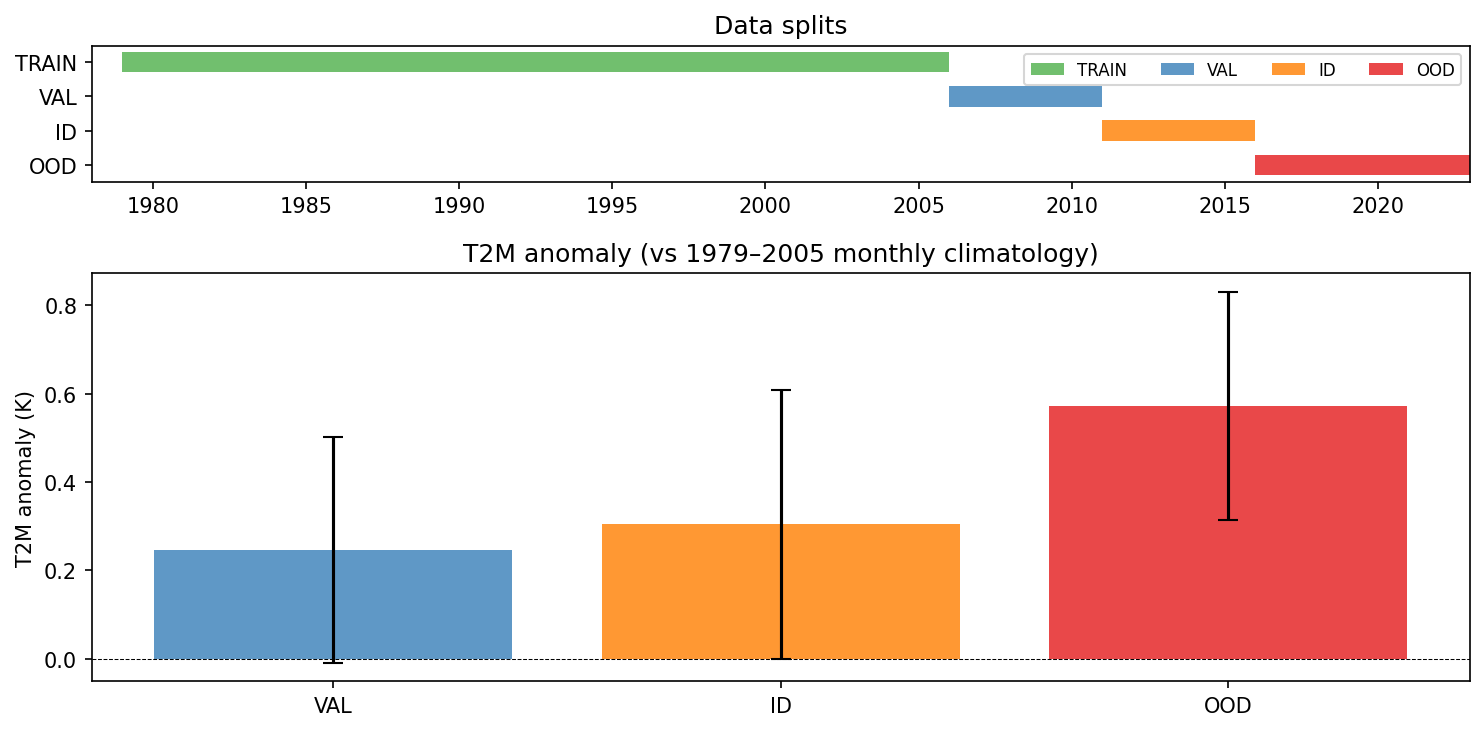

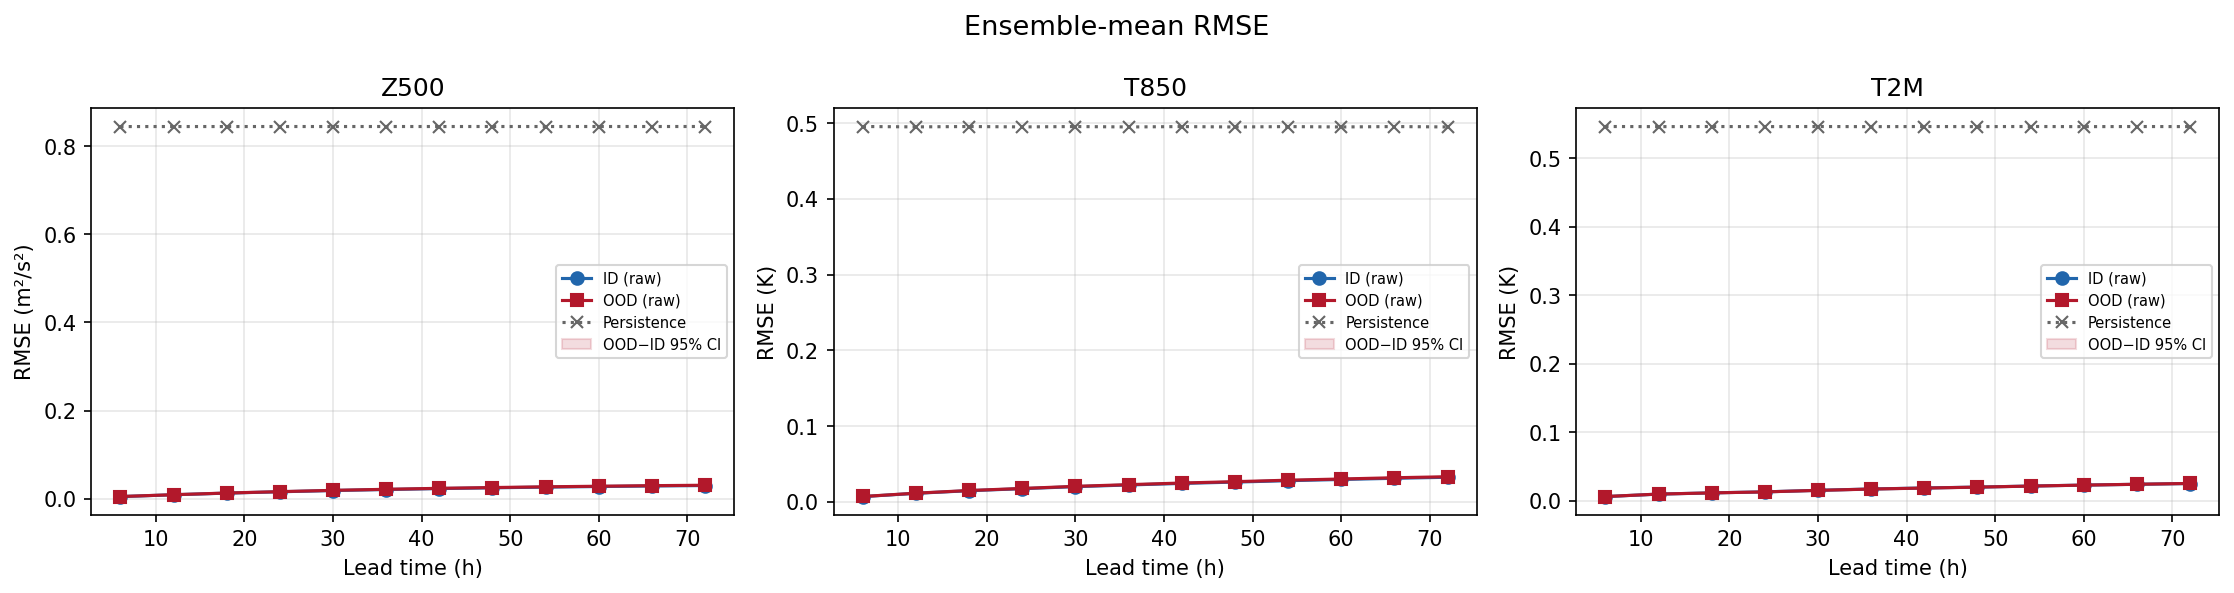

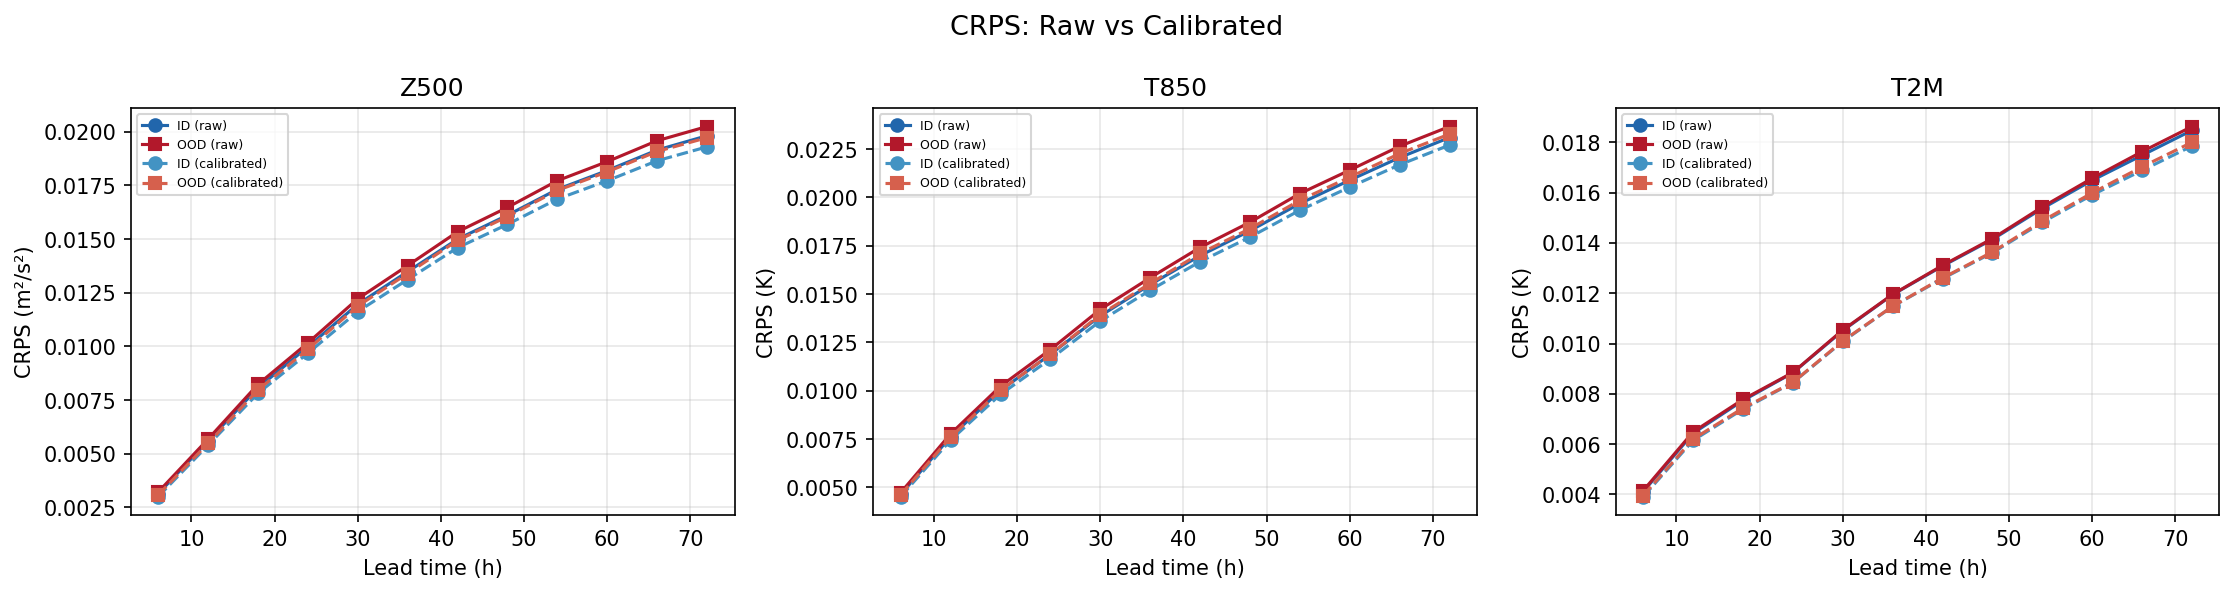

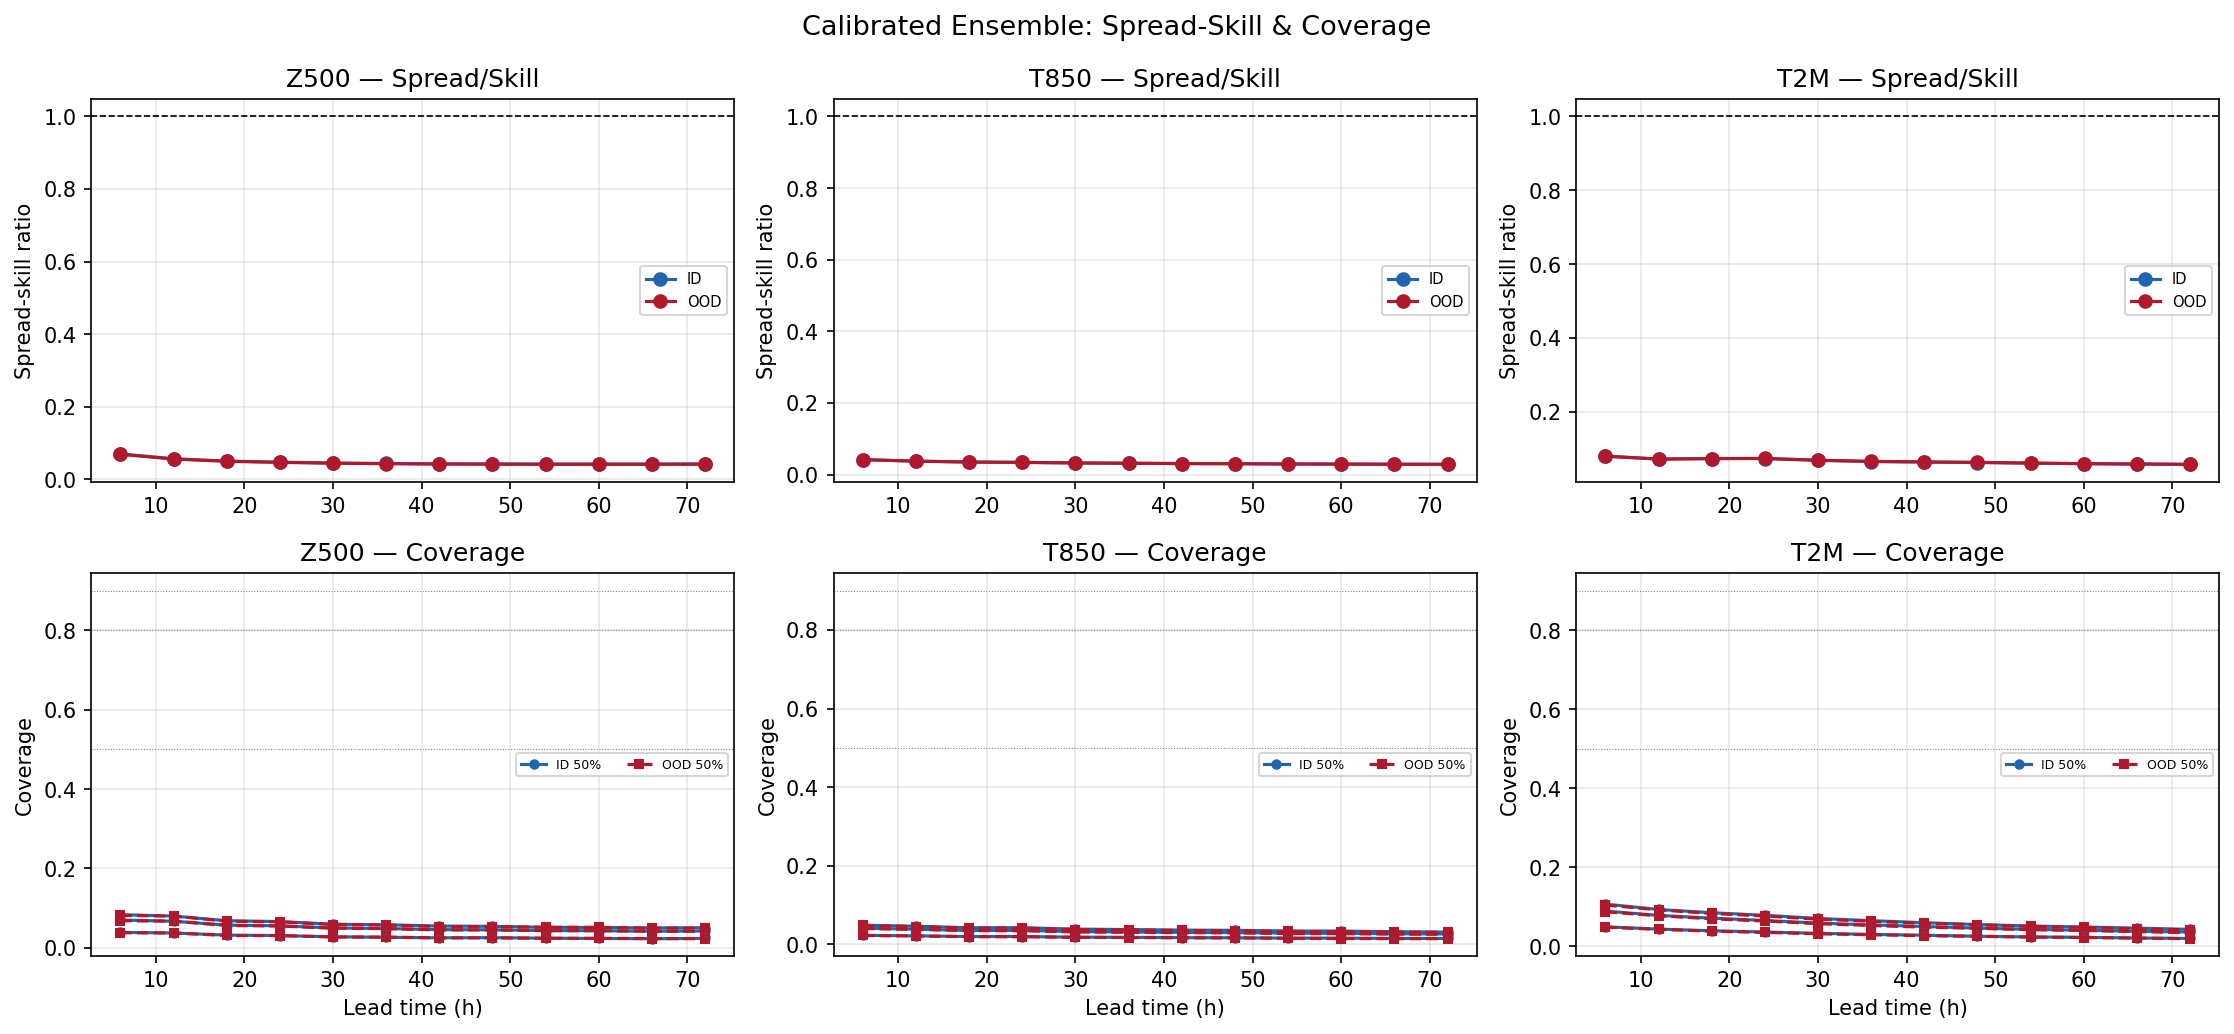

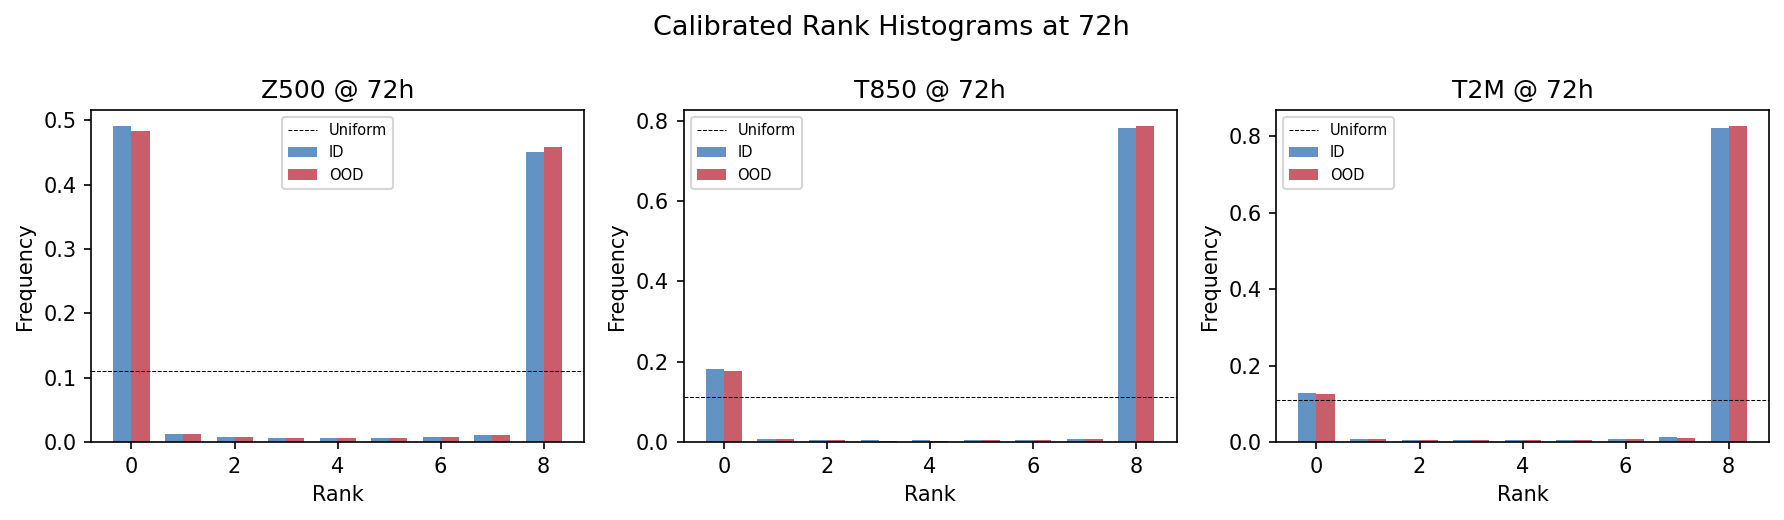

In [22]:
if not DO_PLOT:
    print("Skipping plots.")
else:
    figs_dir = os.path.join(PROJECT_DIR, "figures")
    os.makedirs(figs_dir, exist_ok=True)

    %cd {PROJECT_DIR}
    !python {REPO_DIR}/scripts/plot_shift_results.py \
        --config {CONFIG_PATH} \
        --metrics {os.path.join(PROJECT_DIR, 'results')} \
        --output {figs_dir}

    from IPython.display import Image as IPImg, display
    shown = 0
    for fn in sorted(os.listdir(figs_dir)):
        if fn.endswith(".png"):
            display(IPImg(filename=os.path.join(figs_dir, fn)))
            shown += 1
    if shown == 0:
        print("No PNG previews found; figures are saved as PDFs.")

    drive_figs = os.path.join(DRIVE_ROOT, "figures")
    if os.path.exists(drive_figs):
        shutil.rmtree(drive_figs)
    shutil.copytree(figs_dir, drive_figs)

